In [77]:
import pyscf
import openfermionpyscf
import openfermion as of
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from itertools import combinations

In [85]:
dists = np.linspace(0.5, 2, 8)

orbenes = np.zeros((7, len(dists)))

hf_energies = np.zeros_like(dists)
fci_energies = np.zeros_like(dists)
hf_fci_overlaps = np.zeros_like(dists)

for i, dist in tqdm(enumerate(dists)):


    # geometry = [["N", (0, 0, 0)],
    #             ["N", (0, 0, dist)]]
    geometry = [["H", (0, 0, 0)],
                ["H", (0, 0, 2 * dist)],
                ["O", (0, 0, dist)]
                ]
    # geometry = [["Li", (0, 0, 0)],
    #             ["H", (0, 0, dist)]]
    # geometry = [["H", (0, 0, 0)],
    #             ["H", (0, 0, dist)],
    #             ["H", (0, 0, 2 * dist)],
    #             ["H", (0, 0, 3 * dist)]]

    # geometry = [["H", (0, 0, 0)],
    #             ["H", (0, 1, 0)],
    #             ["H", (0, 0, dist * 1.5)],
    #             ["H", (0, 1, 1.5 * dist)]]
    
    # mol = of.MolecularData(
    #         geometry=geometry,
    #         basis="sto-3g",
    #         multiplicity=1,
    #         charge=0
    #     )
    # mol = openfermionpyscf.run_pyscf(mol, run_scf=True, run_fci=True, run_cisd=False)

    mol = pyscf.M()
    mol.build(atom=geometry, basis="sto-6g")

    
    mf = pyscf.scf.RHF(mol)
    mf.kernel()
    cisolver = pyscf.fci.FCI(mf)
    cisolver.kernel()
    
    orbenes[:, i] = mf.mo_energy
    hf_energies[i] = mf.e_tot
    fci_energies[i] = cisolver.e_tot
    hf_fci_overlaps[i] = cisolver.ci[0][0]**2

0it [00:00, ?it/s]

converged SCF energy = -73.9069287317893


1it [00:00,  4.04it/s]

converged SCF energy = -75.3510064241116


2it [00:00,  4.44it/s]

...

6it [00:01,  4.52it/s]

converged SCF energy = -75.1306656343491


7it [00:01,  4.38it/s]

converged SCF energy = -75.0667378613238


8it [00:01,  4.32it/s]


In [86]:
list(combinations(range(7), 5))[15]

(1, 2, 3, 4, 5)

In [87]:
hf_fci_overlaps

array([9.96500797e-01, 9.91817541e-01, 9.81841447e-01, 9.58952374e-01,
       8.28383936e-14, 3.15862141e-14, 1.29485734e-14, 8.48699918e-12])

In [88]:
mf.e_tot

-75.06673786132379

In [89]:
mf.mo_energy

array([-20.37549505,  -1.03234511,  -0.30226009,  -0.30226009,
        -0.22596247,  -0.03073156,   0.3382655 ])

In [90]:
cisolver.e_tot

-75.45067928080589

In [91]:
cisolver.ci.flatten()[321]

0.33693104252224315

In [92]:
321 // 21

15

In [93]:
321 % 21

6

In [94]:
cisolver.ci.shape

(21, 21)

In [95]:
cisolver.ci[6][15], cisolver.ci[15][6]

(0.3369142776143846, 0.33693104252224315)

In [96]:
np.argmax(cisolver.ci)

321

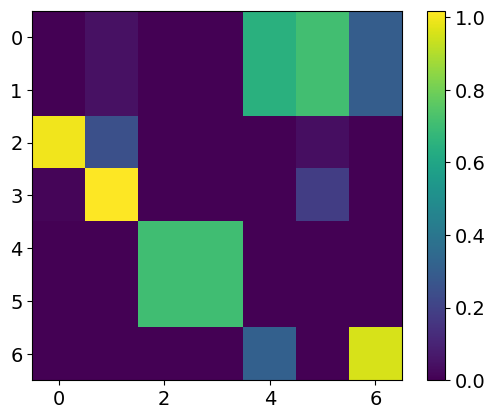

In [98]:
plt.imshow(abs(mf.mo_coeff))
plt.colorbar()

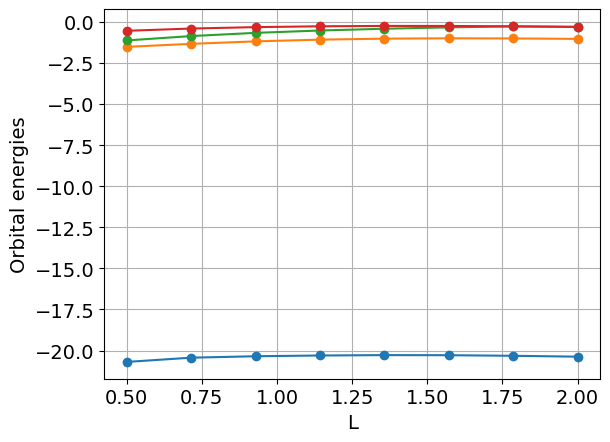

In [67]:
plt.rcParams.update({"font.size":14})
plt.plot(dists, orbenes[0, :], "o-")
plt.plot(dists, orbenes[1, :], "o-")
plt.plot(dists, orbenes[2, :], "o-")
plt.plot(dists, orbenes[3, :], "o-")
# plt.plot(dists, orbenes[4, :], "o-")
# plt.plot(dists, orbenes[5, :], "o-")
# plt.plot(dists, orbenes[1, :] - orbenes[0, :], "o-")
# plt.plot(dists, orbenes[2, :] - orbenes[1, :], "o-")
# plt.plot(dists, orbenes[3, :] - orbenes[2, :], "o-")
plt.xlabel("L")
plt.ylabel("Orbital energies")
# plt.yscale("log")
plt.grid()

In [36]:
dists

array([0.6       , 1.08885714, 1.57771429, 2.06657143, 2.55542857,
       3.04428571, 3.53314286, 4.022     ])